In [13]:
import numpy as np
import matplotlib.pyplot as plt
from tanalysis import improcess, stitching
import pandas as pd
from skimage import exposure


dirname = r"C:\Users\pcanaleta\Documents\Cellpose_segmentation\EXP.HD6.Chips\EXP.HD6.1.1.MatekChips_CXCL10\24h\Originals\24h_CXCL10_Conc10_z5_t8h.lif"

In [14]:
imgs, dim, names, info = improcess.imread(dirname, channel=0, tiles=True)

Reading submitted files: 100%|████████████████████████████████████████| 1/1 [00:31<00:00, 31.33s/it]


All files read!


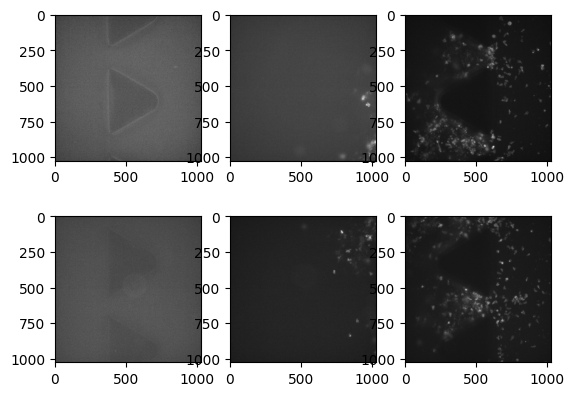

In [15]:
timestamp = imgs[0][0]
positions = info['mosaic_position']
grid = {}
eq_grid = {}
nrow = 0
ncol = 0

for pos, tile in zip(positions, timestamp):
    #Recorder of number of rows and cols
    if pos[1]+1>nrow:
        nrow=pos[1]+1
    if pos[0]+1>ncol:
        ncol=pos[0]+1
    #Assigning to the dictionary the corresponding image to each combination of row, col
    eq_tile = exposure.equalize_hist(tile,)
    grid[f'{pos[1]}{pos[0]}']=tile
    eq_grid[f'{pos[1]}{pos[0]}'] = eq_tile

fig, ax = plt.subplots(2,3)
for row in range(0,2):
    for col in range(0,3):
        ax[row, col].imshow(grid[f'{row}{col}'][5], cmap='gray')

In [16]:
translations = {} #Saving vertical an horizontal translations for each image
z = 7
for row in range(0, nrow):
    for col in range(0, ncol):
        im = eq_grid[f'{row}{col}'][z]
        if row==0:
            Tvrow = 0
            Tvcol = 0
        if col==0:
            Throw = 0
            Thcol = 0
        if row!=0:
            im2 = eq_grid[f'{row-1}{col}'][z]
            _, Tvrow, Tvcol = stitching.pciam(im2, im, n=10)
        if col!=0:
            im2 = eq_grid[f'{row}{col-1}'][z]
            _, Throw, Thcol = stitching.pciam(im2, im, n=10)
        translations[f'{row}{col}'] = [[int(Tvrow), int(Tvcol)], [int(Throw), int(Thcol)]]
print(translations)

{'00': [[0, 0], [0, 0]], '01': [[0, 0], [8, -151]], '02': [[0, 0], [-55, 927]], '10': [[-318, -4], [0, 0]], '11': [[18, 847], [669, -997]], '12': [[850, 27], [-916, 304]]}


In [17]:
# Transform local translations to global translations with reference on image 0
rrow = []
drow = []
rcol = []
dcol = []
for row in np.arange(nrow):
    for col in np.arange(ncol):
        Tv, Th = translations[f'{row}{col}']
        if Tv[1]!=0 and Tv[0]!=0:
            rcol.append(abs(Tv[1]))
            drow.append(abs(Tv[0]))
        if Th[0]!=0 and Th[1]!=0:
            rrow.append(abs(Th[0]))
            dcol.append(abs(Th[1]))

print(rrow, rcol)
print(drow, dcol)
rr = abs(np.min(rrow))
rc = abs(np.min(rcol))
dr = abs(np.max(drow-rr))
dc = abs(np.max(dcol-rc))

print(dr,rr,dc,rc)

[8, 55, 669, 916] [4, 847, 27]
[318, 18, 850] [151, 927, 997, 304]
842 8 993 4


In [18]:
abs_translations = translations
for row in np.arange(nrow):
    for col in np.arange(ncol):
        abs_translations[f'{row}{col}'] = [int(row*(dr+rr)+col*rr), int(row*rc+col*(dc+rc))]
print(abs_translations)

{'00': [0, 0], '01': [8, 997], '02': [16, 1994], '10': [850, 4], '11': [858, 1001], '12': [866, 1998]}


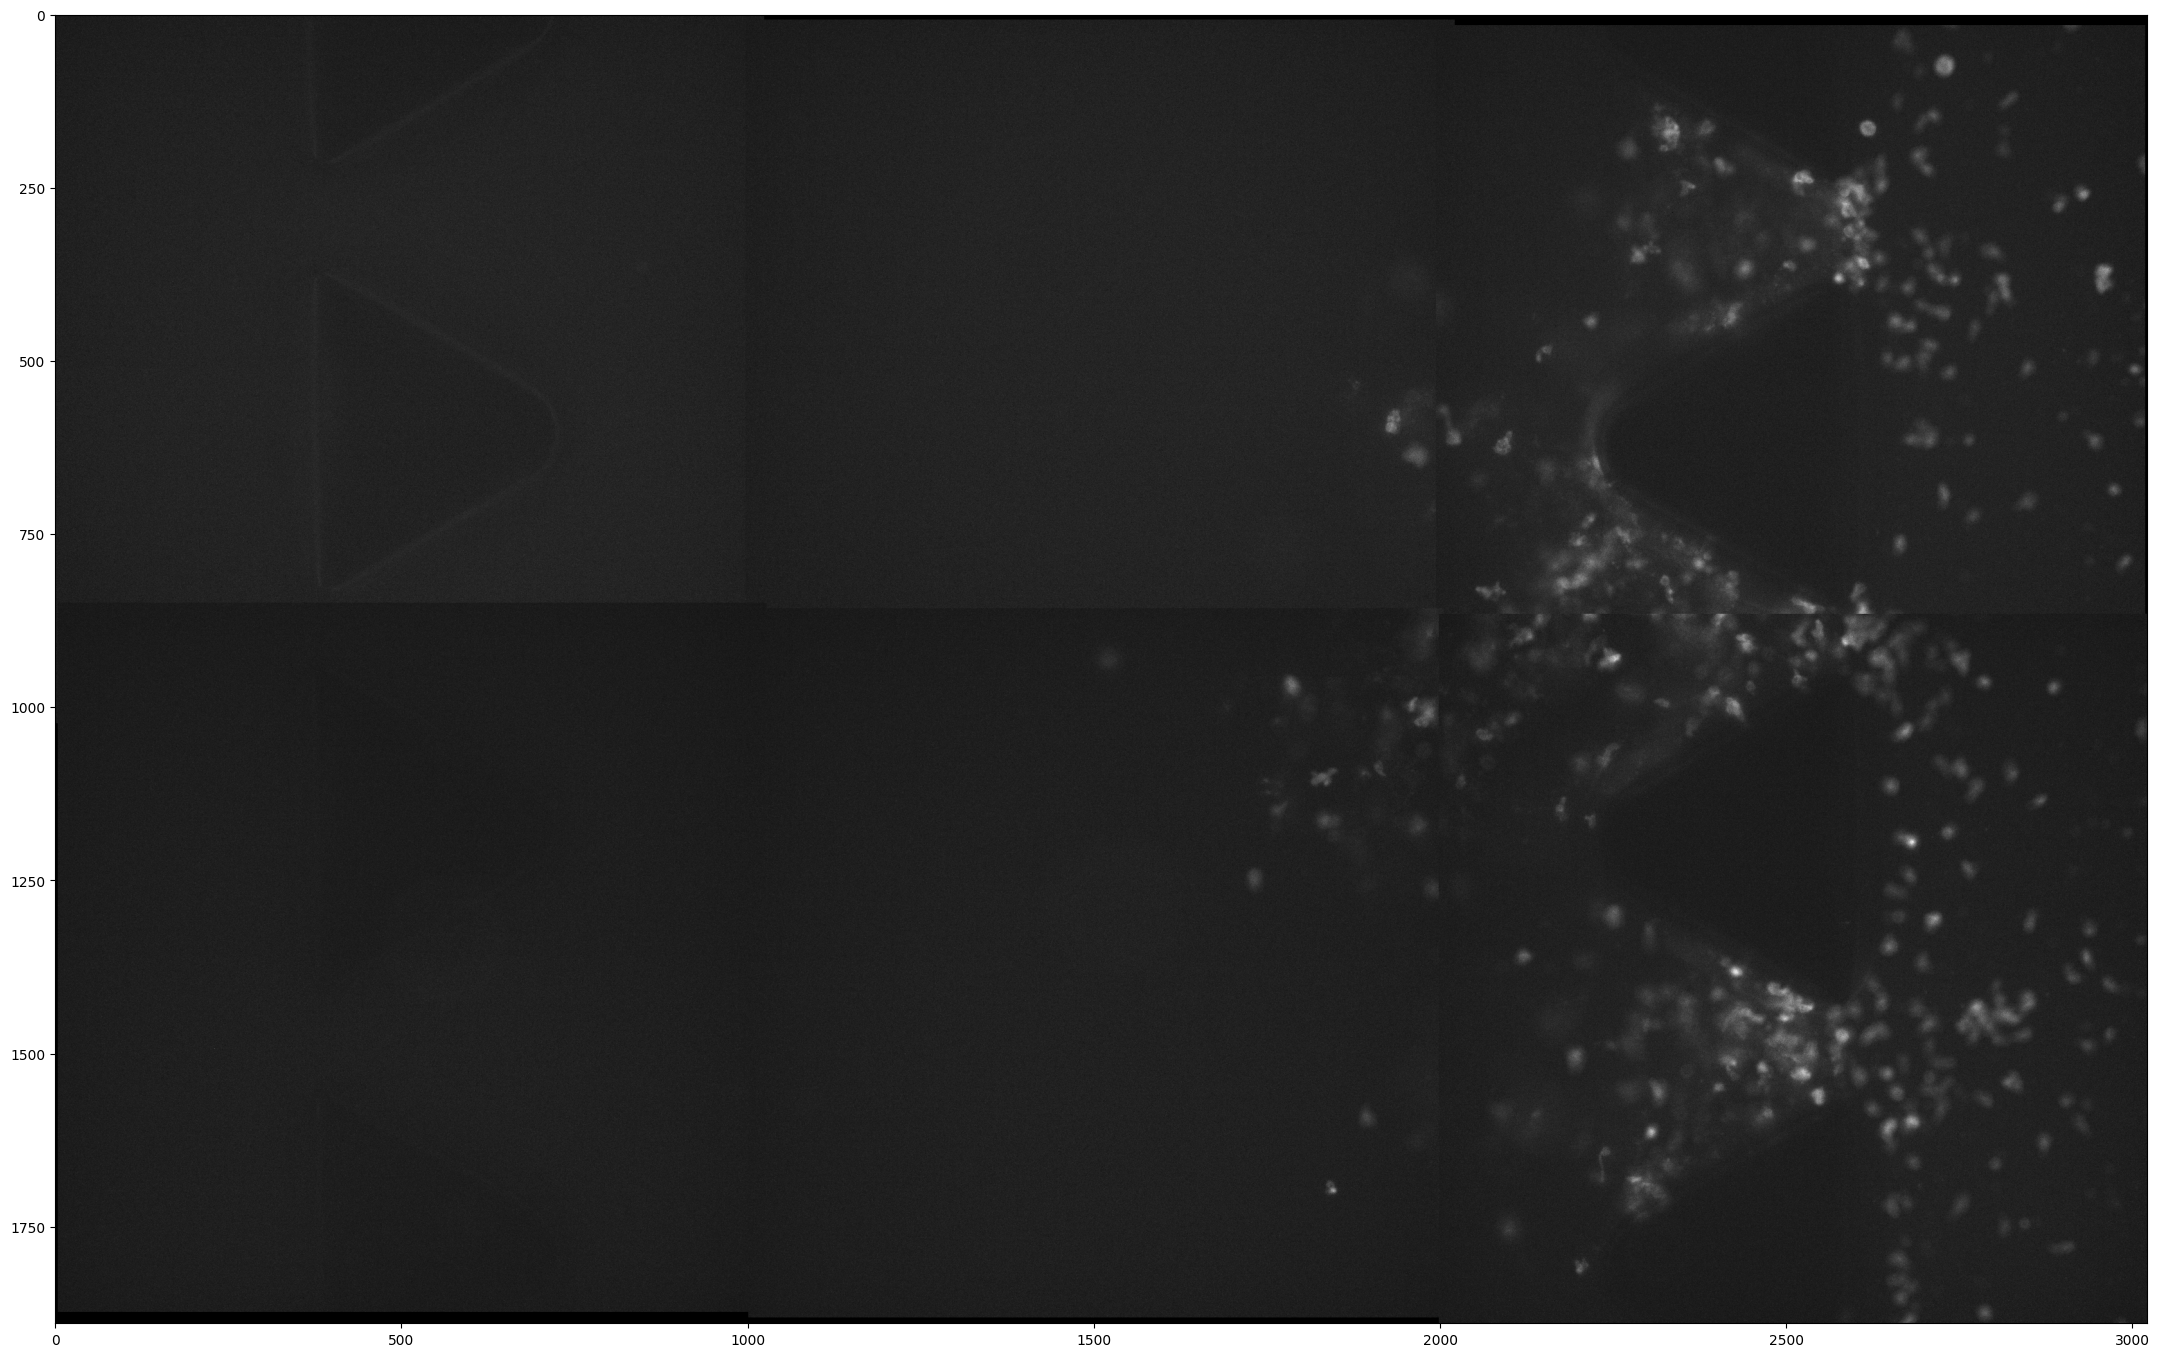

In [20]:
result = np.zeros((866+1024, 1998+1024))
z=7

for trans in abs_translations:
    srow,scol = abs_translations[trans]
    erow = srow+1024
    ecol = scol+1024
    result[srow:erow,scol:ecol] = grid[trans][z]


plt.figure(figsize=(27,48))
plt.imshow(result, cmap='gray')
plt.show()